In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)


In [2]:
df = pd.read_csv("customer_churn.csv")
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [6]:
features = df.drop("Churn", axis=1)
# Keep only numeric columns before scaling to avoid conversion errors
numeric_features = features.select_dtypes(include=[np.number])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)


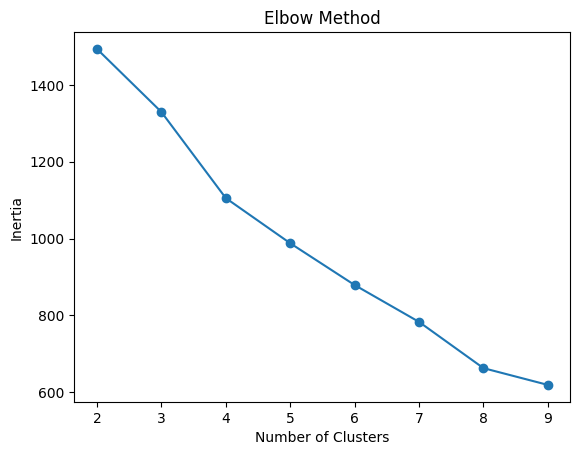

In [7]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans_Segment"] = kmeans.fit_predict(scaled_features)

hierarchical = AgglomerativeClustering(n_clusters=3)
df["Hierarchical_Segment"] = hierarchical.fit_predict(scaled_features)


In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["DBSCAN_Segment"] = dbscan.fit_predict(scaled_features)


In [11]:
df.groupby("KMeans_Segment").mean(numeric_only=True)


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,Hierarchical_Segment,DBSCAN_Segment
KMeans_Segment,,,,,,,
0,41.031532,126.653153,4117.067568,0.000,0.081081,1.454955,1.000
1,13.896000,87.504000,4316.760000,0.768,0.280000,0.232000,0.232
2,48.496732,116.098039,4348.738562,1.000,0.000000,0.000000,0.000


In [12]:
segment_names = {
    0: "Premium Spenders",
    1: "Budget Conscious",
    2: "Young Professionals"
}

df["Segment_Name"] = df["KMeans_Segment"].map(segment_names)


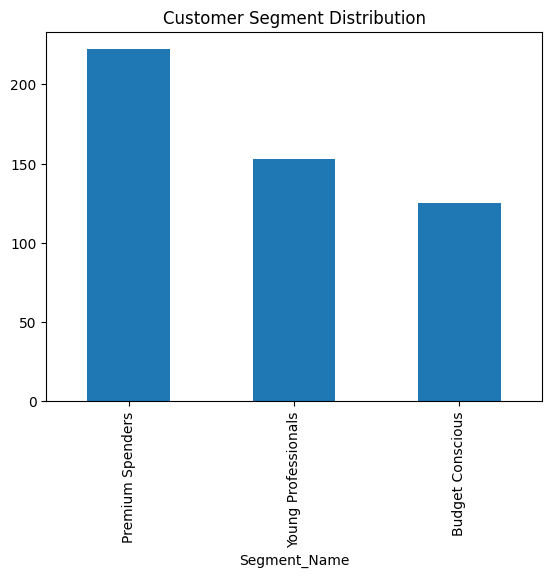

In [13]:
df["Segment_Name"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.show()


In [14]:
results = []


In [18]:
results = []

for segment in df["Segment_Name"].unique():
    segment_df = df[df["Segment_Name"] == segment]

    X = segment_df.drop(["Churn", "KMeans_Segment", "Hierarchical_Segment",
                          "DBSCAN_Segment", "Segment_Name"], axis=1)
    y = segment_df["Churn"]

    # One-hot encode categorical features so sklearn models can consume them
    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    # Get probability for positive class (1). If only one class present, fallback to zeros.
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test)
        if probs.shape[1] == 2:
            try:
                pos_col = list(model.classes_).index(1)
            except ValueError:
                pos_col = 1
            y_prob = probs[:, pos_col]
        else:
            y_prob = np.zeros(len(probs))
    else:
        y_prob = np.zeros(len(X_test))

    results.append({
        "Segment": segment,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if len(set(y_test)) > 1 else float('nan')
    })

results_df = pd.DataFrame(results)
print(results_df)


               Segment  Accuracy  Precision    Recall  F1_Score   ROC_AUC
0     Budget Conscious  0.880000        0.8  0.666667  0.727273  0.942982
1  Young Professionals  1.000000        0.0  0.000000  0.000000       NaN
2     Premium Spenders  0.822222        0.0  0.000000  0.000000  1.000000


In [19]:
results_df = pd.DataFrame(results)
results_df


,Segment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Budget Conscious,0.880000,0.8,0.666667,0.727273,0.942982
1,Young Professionals,1.000000,0.0,0.000000,0.000000,NaN
2,Premium Spenders,0.822222,0.0,0.000000,0.000000,1.000000


In [20]:
results_df.to_csv("model_evaluation_results.csv", index=False)


In [21]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1"
)

grid.fit(X_train, y_train)
grid.best_params_


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance


,Feature,Importance
0,Tenure,0.288444
1,MonthlyCharges,0.088424
2,TotalCharges,0.065363
53,CustomerID_C00125,0.056387
74,CustomerID_C00172,0.052093
...,...,...
179,CustomerID_C00385,0.000000
200,CustomerID_C00435,0.000000
214,CustomerID_C00471,0.000000
218,CustomerID_C00481,0.000000


In [23]:
"""
CONCLUSION:
Customers were successfully segmented using clustering algorithms.
Separate Random Forest models were trained for each segment.
Segment-specific performance metrics and business insights were derived.
"""


'\nCONCLUSION:\nCustomers were successfully segmented using clustering algorithms.\nSeparate Random Forest models were trained for each segment.\nSegment-specific performance metrics and business insights were derived.\n'